In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


csv_file = 'channel_attribution_results_merged_ano.csv'
df = pd.read_csv(csv_file)


In [2]:
df['total_samples_swag'].sum()

168.0

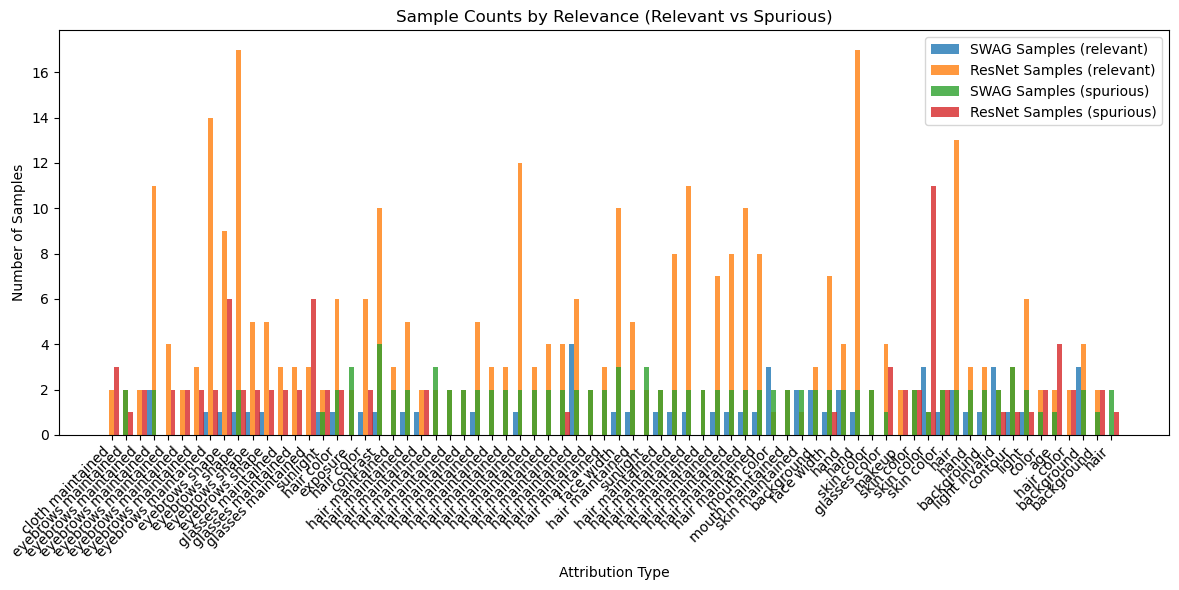

relevance  final_attribution  
relevant   glasses presence       68
           eyes presence           3
spurious   hair maintained        25
           eyebrows maintained     7
           background              4
           eyebrows shape          4
           skin color              4
           glasses maintained      3
           hair color              3
           hand                    3
           face width              2
           hair                    2
           sunlight                2
           age                     1
           cloth maintained        1
           color                   1
           contour                 1
           contrast                1
           exposure                1
           glasses color           1
           light                   1
           light invalid           1
           makeup                  1
           mouth color             1
           mouth maintained        1
           skin maintained         1
Name: c

In [3]:
# Add 'relevance' column based on final_attribution
df['relevance'] = df['final_attribution'].apply(
        lambda x: 'relevant' if x in ['glasses presence', 'eye presence', 'eyes presence'] else 'spurious')
df['total_samples'] = df['total_samples_swag'].fillna(0) + df['total_samples_resnet'].fillna(0)


# Create comparison plot
plt.figure(figsize=(12, 6))
bar_width = 0.35
groups = df.groupby('relevance')

# Plot for each relevance group
for i, (relevance, group) in enumerate(groups):
        index = np.arange(len(group))
        plt.bar(index + i * bar_width, group['total_samples_swag'], bar_width,
                label=f'SWAG Samples ({relevance})', alpha=0.8)
        plt.bar(index + i * bar_width + bar_width, group['total_samples_resnet'], bar_width,
                label=f'ResNet Samples ({relevance})', alpha=0.8)

        plt.xticks(index + bar_width, group['final_attribution'], rotation=45, ha='right')

plt.xlabel('Attribution Type')
plt.ylabel('Number of Samples')
plt.title('Sample Counts by Relevance (Relevant vs Spurious)')
plt.legend()
plt.tight_layout()
plt.show()

# Display the data grouped by relevance
display(df.groupby('relevance')['final_attribution'].value_counts())


In [4]:
(f"total_samples_resnet{df['total_samples_resnet'].sum()} total_samples_swag {df['total_samples_swag'].sum()}")

'total_samples_resnet415.0 total_samples_swag 168.0'

In [5]:
# Calculate frequencies for each model and relevance type
model_relevance_freq = pd.DataFrame({
        'SWAG': df.groupby('relevance')['total_samples_swag'].sum(),
        'ResNet': df.groupby('relevance')['total_samples_resnet'].sum()
})

# Calculate percentages
model_relevance_freq_pct = model_relevance_freq.div(model_relevance_freq.sum()) * 100

# Display both raw counts and percentages
print("Raw counts:")
print(model_relevance_freq)
print("\nPercentages:")
print(model_relevance_freq_pct)

# Print count of rows where relevance is 'relevant' and total_samples_swag > 0
relevant_swag_count = len(df[(df['relevance'] == 'relevant') & (df['total_samples_swag'] > 0)])
print("\nNumber of rows where relevance='relevant' and total_samples_swag > 0:")
print(relevant_swag_count)

# Print count of rows where relevance is 'relevant' and total_samples_swag > 0
relevant_swag_count = len(df[(df['relevance'] == 'spurious') & (df['total_samples_swag'] > 0)])
print("\nNumber of rows where relevance='spurious' and total_samples_swag > 0:")
print(relevant_swag_count)

# Print count of rows where relevance is 'relevant' and total_samples_resnet > 0
relevant_resnet_count = len(df[(df['relevance'] == 'relevant') & (df['total_samples_resnet'] > 0)])
print("\nNumber of rows where relevance='relevant' and total_samples_resnet > 0:")
print(relevant_resnet_count)

# Print count of rows where relevance is 'relevant' and total_samples_resnet > 0
relevant_resnet_count = len(df[(df['relevance'] == 'spurious') & (df['total_samples_resnet'] > 0)])
print("\nNumber of rows where relevance='spurious' and total_samples_resnet > 0:")
print(relevant_resnet_count)

Raw counts:
            SWAG  ResNet
relevance               
relevant    55.0   335.0
spurious   113.0    80.0

Percentages:
                SWAG     ResNet
relevance                      
relevant   32.738095  80.722892
spurious   67.261905  19.277108

Number of rows where relevance='relevant' and total_samples_swag > 0:
39

Number of rows where relevance='spurious' and total_samples_swag > 0:
56

Number of rows where relevance='relevant' and total_samples_resnet > 0:
71

Number of rows where relevance='spurious' and total_samples_resnet > 0:
33


In [6]:
df[(df['relevance'] == 'spurious') & (df['total_samples_resnet'] > 0)]

,layer_name,channel_id,attribution_swag,confidence_swag,attribution_resnet,confidence_resnet,total_samples_swag,total_samples_resnet,final_attribution,relevance,total_samples
0,b4.conv1.affine,479,NaN,NaN,cloth maintained,0.666667,NaN,3.0,cloth maintained,spurious,3.0
1,b32.conv0.affine,120,eyebrows maintained,1.0,eyebrows maintained,1.000000,2.0,1.0,eyebrows maintained,spurious,3.0
2,b32.conv1.affine,168,NaN,NaN,eyebrows maintained,1.000000,NaN,2.0,eyebrows maintained,spurious,2.0
4,b128.conv0.affine,160,NaN,NaN,eyebrows maintained,1.000000,NaN,2.0,eyebrows maintained,spurious,2.0
5,b128.conv0.affine,199,NaN,NaN,eyebrows maintained,1.000000,NaN,2.0,eyebrows maintained,spurious,2.0
6,b64.conv1.affine,332,NaN,NaN,eyebrows maintained,1.000000,NaN,2.0,eyebrows maintained,spurious,2.0
7,b128.conv0.affine,286,NaN,NaN,eyebrows maintained,1.000000,NaN,2.0,eyebrows maintained,spurious,2.0
8,b32.conv0.affine,6,NaN,NaN,eyebrows shape,1.000000,NaN,6.0,eyebrows shape,spurious,6.0
9,b16.conv1.affine,179,eyebrows shape,1.0,eyebrows shape,1.000000,2.0,2.0,eyebrows shape,spurious,4.0
10,b32.conv1.affine,135,NaN,NaN,eyebrows shape,1.000000,NaN,2.0,eyebrows shape,spurious,2.0


In [7]:
df_relevant = df[df['relevance'] == 'relevant'].sort_values('total_samples', ascending=False)
df_spurious = df[df['relevance'] == 'spurious'].sort_values('total_samples', ascending=False)


In [8]:
df_spurious

,layer_name,channel_id,attribution_swag,confidence_swag,attribution_resnet,confidence_resnet,total_samples_swag,total_samples_resnet,final_attribution,relevance,total_samples
109,b256.conv1.affine,97,hair color,1.0,skin color,0.818182,1.0,11.0,skin color,spurious,12.0
17,b64.conv1.affine,327,NaN,NaN,glasses maintained,0.833333,NaN,6.0,glasses maintained,spurious,6.0
8,b32.conv0.affine,6,NaN,NaN,eyebrows shape,1.000000,NaN,6.0,eyebrows shape,spurious,6.0
121,b32.conv1.affine,435,eyebrows shape,1.0,age,0.500000,1.0,4.0,age,spurious,5.0
110,b256.conv1.affine,27,hair color,1.0,face color,0.500000,2.0,2.0,skin color,spurious,4.0
...,...,...,...,...,...,...,...,...,...,...,...
75,b32.conv0.affine,220,hair maintained,1.0,NaN,NaN,2.0,NaN,hair maintained,spurious,2.0
76,b32.conv0.affine,339,hair maintained,1.0,NaN,NaN,2.0,NaN,hair maintained,spurious,2.0
77,b128.conv0.affine,497,hair maintained,1.0,NaN,NaN,2.0,NaN,hair maintained,spurious,2.0
78,b128.conv0.affine,53,hair maintained,1.0,NaN,NaN,2.0,NaN,hair maintained,spurious,2.0


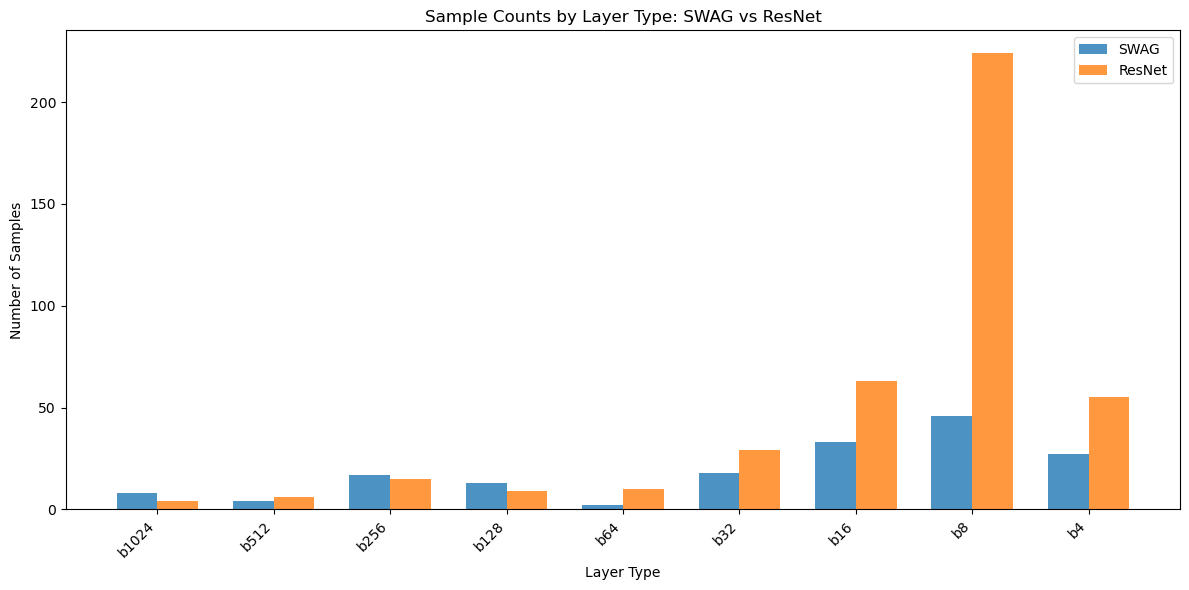

,layer_type,total_samples_swag,total_samples_resnet
0,b1024,8.0,4.0
6,b512,4.0,6.0
3,b256,17.0,15.0
1,b128,13.0,9.0
7,b64,2.0,10.0
4,b32,18.0,29.0
2,b16,33.0,63.0
8,b8,46.0,224.0
5,b4,27.0,55.0


In [9]:
# Group by layer type
df['layer_type'] = df['layer_name'].apply(lambda x: x.split('.')[0])

plt.figure(figsize=(12, 6))
bar_width = 0.35

# Calculate the aggregated counts by layer type and sort by layer size
layer_counts = df.groupby('layer_type').agg({
        'total_samples_swag': 'sum',
        'total_samples_resnet': 'sum'
}).reset_index()

# Sort layers by size (1024, 512, ..., 4)
size_order = ['b1024', 'b512', 'b256', 'b128', 'b64', 'b32', 'b16', 'b8', 'b4']
layer_counts['layer_type'] = pd.Categorical(layer_counts['layer_type'],
                                            categories=size_order,
                                            ordered=True)
layer_counts = layer_counts.sort_values('layer_type')

# Create bar positions
x = np.arange(len(layer_counts))

# Create bars
plt.bar(x - bar_width / 2, layer_counts['total_samples_swag'], bar_width,
        label='SWAG', alpha=0.8)
plt.bar(x + bar_width / 2, layer_counts['total_samples_resnet'], bar_width,
        label='ResNet', alpha=0.8)

# Customize plot
plt.xlabel('Layer Type')
plt.ylabel('Number of Samples')
plt.title('Sample Counts by Layer Type: SWAG vs ResNet')
plt.xticks(x, layer_counts['layer_type'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Display the counts
display(layer_counts)


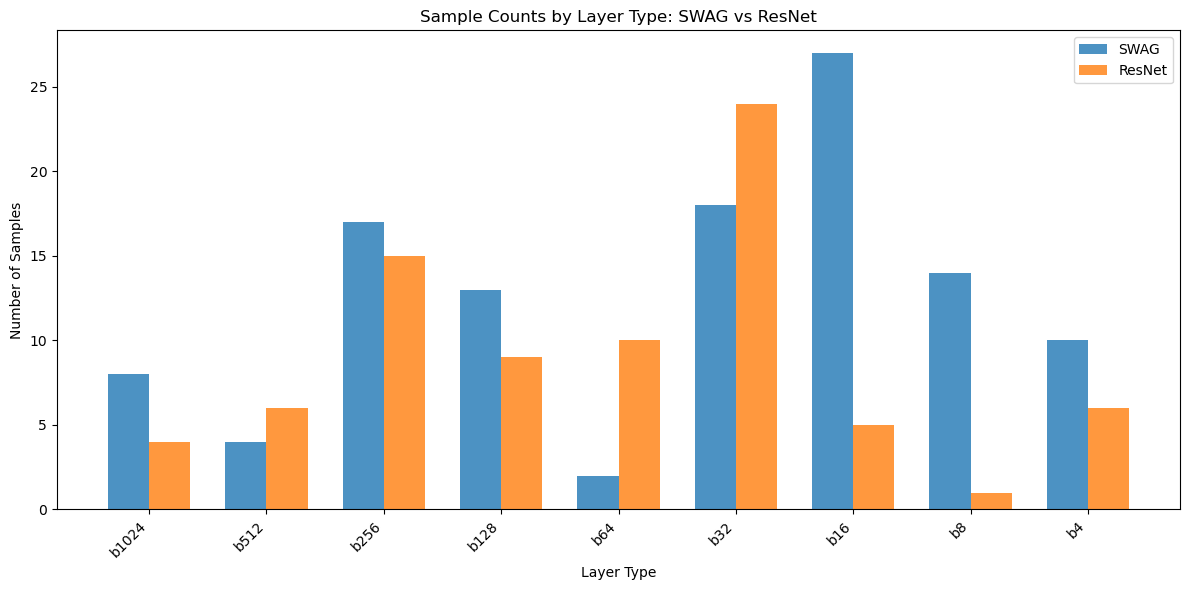

,layer_type,total_samples_swag,total_samples_resnet
0,b1024,8.0,4.0
6,b512,4.0,6.0
3,b256,17.0,15.0
1,b128,13.0,9.0
7,b64,2.0,10.0
4,b32,18.0,24.0
2,b16,27.0,5.0
8,b8,14.0,1.0
5,b4,10.0,6.0


In [10]:
# Group by layer type
df_spurious['layer_type'] = df_spurious['layer_name'].apply(lambda x: x.split('.')[0])

plt.figure(figsize=(12, 6))
bar_width = 0.35

# Calculate the aggregated counts by layer type
layer_counts = df_spurious.groupby('layer_type').agg({
        'total_samples_swag': 'sum',
        'total_samples_resnet': 'sum'
}).reset_index()
# Sort layers by size (1024, 512, ..., 4)
size_order = ['b1024', 'b512', 'b256', 'b128', 'b64', 'b32', 'b16', 'b8', 'b4']
layer_counts['layer_type'] = pd.Categorical(layer_counts['layer_type'],
                                            categories=size_order,
                                            ordered=True)
layer_counts = layer_counts.sort_values('layer_type')
# Create bar positions
x = np.arange(len(layer_counts))

# Create bars
plt.bar(x - bar_width / 2, layer_counts['total_samples_swag'], bar_width,
        label='SWAG', alpha=0.8)
plt.bar(x + bar_width / 2, layer_counts['total_samples_resnet'], bar_width,
        label='ResNet', alpha=0.8)

# Customize plot
plt.xlabel('Layer Type')
plt.ylabel('Number of Samples')
plt.title('Sample Counts by Layer Type: SWAG vs ResNet')
plt.xticks(x, layer_counts['layer_type'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Display the counts
display(layer_counts)

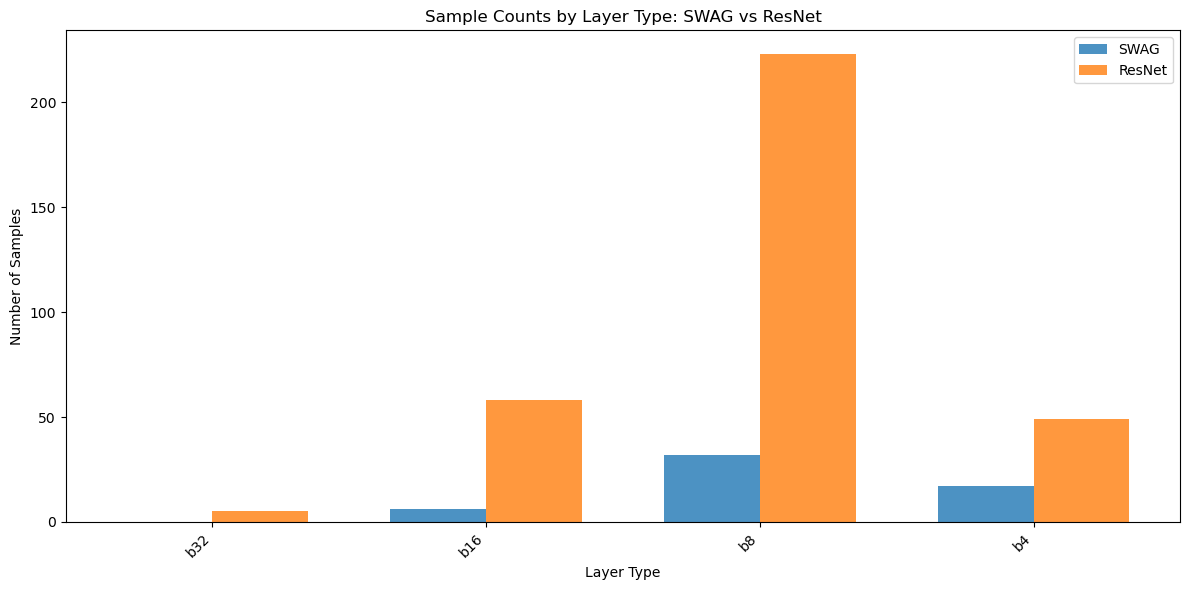

,layer_type,total_samples_swag,total_samples_resnet
1,b32,0.0,5.0
0,b16,6.0,58.0
3,b8,32.0,223.0
2,b4,17.0,49.0


In [11]:
# Group by layer type
df_relevant['layer_type'] = df_relevant['layer_name'].apply(lambda x: x.split('.')[0])

plt.figure(figsize=(12, 6))
bar_width = 0.35

# Calculate the aggregated counts by layer type
layer_counts = df_relevant.groupby('layer_type').agg({
        'total_samples_swag': 'sum',
        'total_samples_resnet': 'sum'
}).reset_index()
# Sort layers by size (1024, 512, ..., 4)
size_order = ['b1024', 'b512', 'b256', 'b128', 'b64', 'b32', 'b16', 'b8', 'b4']
layer_counts['layer_type'] = pd.Categorical(layer_counts['layer_type'],
                                            categories=size_order,
                                            ordered=True)
layer_counts = layer_counts.sort_values('layer_type')
# Create bar positions
x = np.arange(len(layer_counts))

# Create bars
plt.bar(x - bar_width / 2, layer_counts['total_samples_swag'], bar_width,
        label='SWAG', alpha=0.8)
plt.bar(x + bar_width / 2, layer_counts['total_samples_resnet'], bar_width,
        label='ResNet', alpha=0.8)

# Customize plot
plt.xlabel('Layer Type')
plt.ylabel('Number of Samples')
plt.title('Sample Counts by Layer Type: SWAG vs ResNet')
plt.xticks(x, layer_counts['layer_type'], rotation=45, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Display the counts
display(layer_counts)

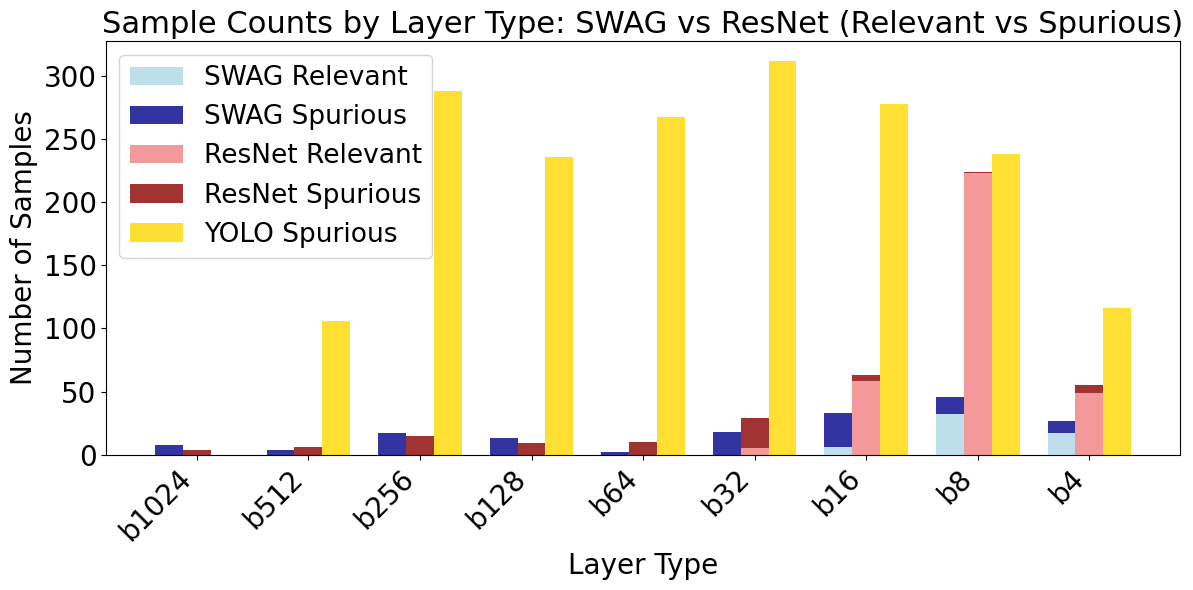

SWAG data:


relevance,relevant,spurious
layer_type,,
b1024,0.0,8.0
b512,0.0,4.0
b256,0.0,17.0
b128,0.0,13.0
b64,0.0,2.0
b32,0.0,18.0
b16,6.0,27.0
b8,32.0,14.0
b4,17.0,10.0



ResNet data:


relevance,relevant,spurious
layer_type,,
b1024,0.0,4.0
b512,0.0,6.0
b256,0.0,15.0
b128,0.0,9.0
b64,0.0,10.0
b32,5.0,24.0
b16,58.0,5.0
b8,223.0,1.0
b4,49.0,6.0



Total statistics:
SWAG total samples: 168.0
ResNet total samples: 415.0
Total samples: 583.0


In [24]:
# Create merged stacked bar chart: categorized by layer_type, two bars per layer_type (ResNet and SWAG), each bar divided into two segments (relevant and spurious)
df['layer_type'] = df['layer_name'].apply(lambda x: x.split('.')[0])

# Aggregate data by layer_type and relevance 
layer_relevance_counts = df.groupby(['layer_type', 'relevance']).agg({
    'total_samples_swag': 'sum',
    'total_samples_resnet': 'sum'
}).reset_index()

# Create pivot tables for plotting
pivot_swag = layer_relevance_counts.pivot(index='layer_type', columns='relevance', values='total_samples_swag').fillna(
    0)
pivot_resnet = layer_relevance_counts.pivot(index='layer_type', columns='relevance',
                                            values='total_samples_resnet').fillna(0)

# Ensure column order (relevant, spurious)
for pivot in [pivot_swag, pivot_resnet]:
    if 'relevant' not in pivot.columns:
        pivot['relevant'] = 0
    if 'spurious' not in pivot.columns:
        pivot['spurious'] = 0

pivot_swag = pivot_swag[['relevant', 'spurious']]
pivot_resnet = pivot_resnet[['relevant', 'spurious']]

# 
# Convert yolo_result to DataFrame format
yolo_result = {'b16': 278,
         'b256': 288,
         'b32': 312,
         'b8': 238,
         'b64': 268,
         'b512': 106,
         'b128': 236,
         'b4': 116,'b1024': 0}
pivot_yolo = pd.DataFrame.from_dict(yolo_result, orient='index', columns=['spurious'])
pivot_yolo.index.name = 'layer_type'

# Set layer order
size_order = ['b1024', 'b512', 'b256', 'b128', 'b64', 'b32', 'b16', 'b8', 'b4']
pivot_swag = pivot_swag.reindex([layer for layer in size_order if layer in pivot_swag.index])
pivot_resnet = pivot_resnet.reindex([layer for layer in size_order if layer in pivot_resnet.index])
pivot_yolo = pivot_yolo.reindex([layer for layer in size_order if layer in pivot_yolo.index])


# Create plot
fig = plt.figure(figsize=(12, 6), facecolor='none')
bar_width = 0.25
x = np.arange(len(pivot_swag.index))

# Plot SWAG bars (left side)
plt.bar(x - bar_width , pivot_swag['relevant'], bar_width,
        label='SWAG Relevant', color='lightblue', alpha=0.8)
plt.bar(x - bar_width , pivot_swag['spurious'], bar_width,
        bottom=pivot_swag['relevant'], label='SWAG Spurious', color='darkblue', alpha=0.8)

# Plot ResNet bars (right side)
plt.bar(x , pivot_resnet['relevant'], bar_width,
        label='ResNet Relevant', color='lightcoral', alpha=0.8)
plt.bar(x , pivot_resnet['spurious'], bar_width,
        bottom=pivot_resnet['relevant'], label='ResNet Spurious', color='darkred', alpha=0.8)

# plot YOLO bars
plt.bar(x + bar_width, pivot_yolo['spurious'], bar_width,
        label='YOLO Spurious', color='gold', alpha=0.8)
plt.gca().set_facecolor('none')
plt.grid(False)
plt.xlabel('Layer Type', fontsize=20)
plt.ylabel('Number of Samples', fontsize=20)
plt.title('Sample Counts by Layer Type: SWAG vs ResNet (Relevant vs Spurious)', fontsize=22)
plt.xticks(x, pivot_swag.index, rotation=45, ha='right', fontsize=20)
plt.legend(loc='upper left', fontsize=19)
plt.yticks(fontsize=20)
plt.tight_layout()
plt.savefig('layer_type_comparison.svg', format='svg', dpi=300, bbox_inches='tight', facecolor='none')
plt.show()

# Display detailed data
print("SWAG data:")
display(pivot_swag)
print("\nResNet data:")
display(pivot_resnet)

# Display totals 
print("\nTotal statistics:")
swag_total = pivot_swag.sum().sum()
resnet_total = pivot_resnet.sum().sum()
print(f"SWAG total samples: {swag_total}")
print(f"ResNet total samples: {resnet_total}")
print(f"Total samples: {swag_total + resnet_total}")


In [ ]:
# Filter out spurious data and sort by frequency
df_spurious_sorted = df[df['relevance'] == 'spurious'].sort_values('total_samples', ascending=False)

print("=== Most Frequent Spurious Data ===")
print("\n--- SWAG Model Spurious Data (Sorted by Frequency) ---")
swag_spurious = df_spurious_sorted[df_spurious_sorted['total_samples_swag'] > 0].sort_values('total_samples_swag',
                                                                                             ascending=False)
print(f"Total SWAG spurious data rows: {len(swag_spurious)}")
print("\nTop 10 highest frequency SWAG spurious data:")
print(swag_spurious[['layer_name', 'channel_id', 'final_attribution', 'total_samples_swag']].head(10))

print("\n--- ResNet Model Spurious Data (Sorted by Frequency) ---")
resnet_spurious = df_spurious_sorted[df_spurious_sorted['total_samples_resnet'] > 0].sort_values('total_samples_resnet',
                                                                                                 ascending=False)
print(f"Total ResNet spurious data rows: {len(resnet_spurious)}")
print("\nTop 10 highest frequency ResNet spurious data:")
print(resnet_spurious[['layer_name', 'channel_id', 'final_attribution', 'total_samples_resnet']].head(10))


In [26]:
top_10_features_yolo = [('Saturation', 7),
 ('Brightness', 6),
 ('Bumper', 6),
 ('Bronze Tint', 5),
 ('Background', 5),
 ('Red Spotting', 5),
 ('Tree Background', 5),
 ('Contrast', 5),
 ('Washed Vintage Tone', 5),
 ('Headlights', 5)] 

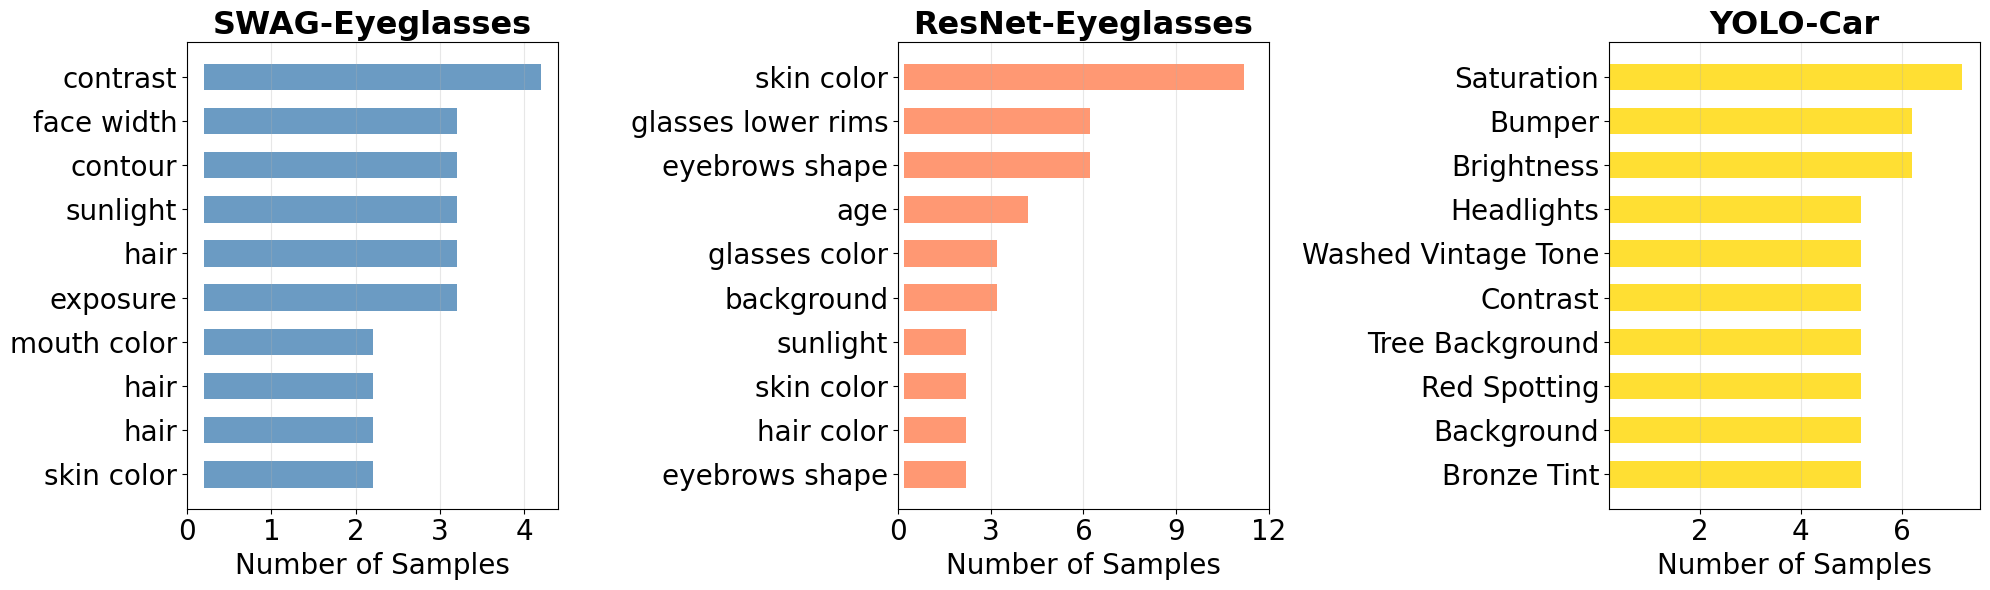


=== Top 10 YOLO Spurious Features ===
- Total feature occurrences: 54
- Average occurrences per feature: 5.4
- Most frequent feature: Saturation (7 occurrences)
=== Top 10 Spurious Attribution Summary ===

SWAG Model:
- Total spurious samples: 27.0
- Average samples per attribution: 2.7
- Most frequent spurious attribution: contrast (4.0 samples)

ResNet Model:
- Total spurious samples: 41.0
- Average samples per attribution: 4.1
- Most frequent spurious attribution: skin color (11.0 samples)


In [32]:
# Filter spurious data and sort by frequency
df_spurious_sorted = df[df['relevance'] == 'spurious'].sort_values('total_samples', ascending=False)

# Create horizontal bar charts for top 10 spurious data 
fig, (ax1, ax2,ax3) = plt.subplots(1, 3, figsize=(20, 6))
plt.subplots_adjust(wspace=0.1)  # Reduce spacing between subplots

# SWAG model spurious data (top 10)
swag_spurious = df_spurious_sorted[df_spurious_sorted['total_samples_swag'] > 0].sort_values('total_samples_swag',ascending=True).tail(10)

bars1 = ax1.barh(range(len(swag_spurious)), swag_spurious['total_samples_swag'], color='steelblue', alpha=0.8,
                 height=0.6, left=0.2)  # Added left margin
ax1.set_yticks(range(len(swag_spurious)))
ax1.set_yticklabels(swag_spurious['final_attribution'], fontsize=20)

custom_labels_swag = list(swag_spurious['final_attribution'])
custom_labels_swag = [label.replace(' maintained', '') for label in custom_labels_swag]
ax1.set_yticklabels(custom_labels_swag, fontsize=20)
ax1.set_facecolor('none')
ax1.set_title('SWAG-Eyeglasses', fontsize=23, fontweight='bold')
ax1.set_xlabel('Number of Samples', fontsize=20)
ax1.set_xticks([0, 1, 2, 3, 4])
ax1.tick_params(axis='x', labelsize=20)
ax1.grid(axis='x', alpha=0.3)

# ResNet model spurious data (top 10)
resnet_spurious = df_spurious_sorted[df_spurious_sorted['total_samples_resnet'] > 0].sort_values('total_samples_resnet',ascending=True).tail(10)

bars2 = ax2.barh(range(len(resnet_spurious)), resnet_spurious['total_samples_resnet'], color='coral', alpha=0.8,
                 height=0.6, left=0.2)  # Added left margin
ax2.set_yticks(range(len(resnet_spurious)))
ax2.set_yticklabels(resnet_spurious['final_attribution'], fontsize=20)

# Manually modify specific labels
custom_labels_resnet = list(resnet_spurious['final_attribution'])
custom_labels_resnet[8] = 'glasses lower rims'  # Example modification
custom_labels_resnet[4] = 'background'  # Example modification
ax2.set_yticklabels(custom_labels_resnet, fontsize=20)

ax2.set_title('ResNet-Eyeglasses', fontsize=23, fontweight='bold')
ax2.set_xlabel('Number of Samples', fontsize=20)
ax2.set_xticks([0, 3, 6, 9, 12])
ax2.tick_params(axis='x', labelsize=20)
ax2.grid(axis='x', alpha=0.3)

# Create comparison with YOLO top 10 features
# fig, ax3 = plt.subplots(figsize=(14, 6))

yolo_features_df = pd.DataFrame(top_10_features_yolo, columns=['feature', 'count']).sort_values('count', ascending=True)

bars3 = ax3.barh(range(len(yolo_features_df)), yolo_features_df['count'], color='gold', alpha=0.8, height=0.6, left=0.2)
ax3.set_yticks(range(len(yolo_features_df)))
ax3.set_yticklabels(yolo_features_df['feature'], fontsize=20)
ax3.set_title('YOLO-Car', fontsize=23, fontweight='bold')
ax3.set_xlabel('Number of Samples', fontsize=20)
ax3.tick_params(axis='x', labelsize=20)
ax3.grid(axis='x', alpha=0.3)
ax3.set_facecolor('none')

plt.gca().set_facecolor('none')
plt.tight_layout()
plt.savefig('top10_spurious.svg', format='svg', dpi=300, bbox_inches='tight')
plt.show()

print("\n=== Top 10 YOLO Spurious Features ===")
print(f"- Total feature occurrences: {yolo_features_df['count'].sum()}")
print(f"- Average occurrences per feature: {yolo_features_df['count'].mean():.1f}")
print(f"- Most frequent feature: {yolo_features_df.iloc[-1]['feature']} ({yolo_features_df.iloc[-1]['count']} occurrences)")
# Print summary statistics
print("=== Top 10 Spurious Attribution Summary ===")
print(f"\nSWAG Model:")
print(f"- Total spurious samples: {swag_spurious['total_samples_swag'].sum()}")
print(f"- Average samples per attribution: {swag_spurious['total_samples_swag'].mean():.1f}")
print(
    f"- Most frequent spurious attribution: {swag_spurious.iloc[-1]['final_attribution']} ({swag_spurious.iloc[-1]['total_samples_swag']} samples)")

print(f"\nResNet Model:")
print(f"- Total spurious samples: {resnet_spurious['total_samples_resnet'].sum()}")
print(f"- Average samples per attribution: {resnet_spurious['total_samples_resnet'].mean():.1f}")
print(
    f"- Most frequent spurious attribution: {resnet_spurious.iloc[-1]['final_attribution']} ({resnet_spurious.iloc[-1]['total_samples_resnet']} samples)")


In [15]:
print("\n=== Spurious data sorted by total samples ===")
print("Top 10 highest frequency spurious data (SWAG + ResNet):")
print(df_spurious_sorted[
          ['layer_name', 'channel_id', 'final_attribution', 'total_samples_swag', 'total_samples_resnet',
           'total_samples']].head(10))

# Display distribution of spurious attribution types
print("\n=== Distribution of Spurious Attribution Types ===")
spurious_attribution_counts = df_spurious_sorted['final_attribution'].value_counts()
print(spurious_attribution_counts)



=== 按总样本数排序的spurious数据 ===
前10行最高频率的spurious数据（SWAG + ResNet）:
             layer_name  channel_id   final_attribution  total_samples_swag  \
109   b256.conv1.affine          97          skin color                 1.0   
17     b64.conv1.affine         327  glasses maintained                 NaN   
8      b32.conv0.affine           6      eyebrows shape                 NaN   
121    b32.conv1.affine         435                 age                 1.0   
110   b256.conv1.affine          27          skin color                 2.0   
52   b1024.conv0.affine          48            contrast                 4.0   
118   b128.conv1.affine         120             contour                 3.0   
49    b512.conv1.affine          46          hair color                 2.0   
9      b16.conv1.affine         179      eyebrows shape                 2.0   
108   b256.conv1.affine         117          skin color                 2.0   

     total_samples_resnet  total_samples  
109                  11